In [2]:
import itertools
import string
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC, LinearSVC
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

### Loading in the dataset

In [ ]:
cwd = Path.cwd()

data = pd.read_csv(cwd.parent/'leda_extractie_labeled.csv', sep = '|')

### Data Cleaning
Since the data that we receive is rarely pristine, we want to make sure we clean up the data before we start using it.

In the pre-labeled dataset, there are several issues that need to be addressed:
1. Some rows are completely populated by NaN values and do not provide any value for classification. These can be removed.
2. Some rows are duplicates of other rows and should be removed, as they would pollute the training data.
3. Some rows do not contain a label. These should be removed before training (using supervised ML models). 
4. Some rows are missing food item names, these are removed for now for optimising the training.

In [4]:
# General use functionality.

def apply_steps_sequentially(data: pd.DataFrame, steps: list, available_steps: dict) -> pd.DataFrame:
    """Apply steps defined in the provided steps in sequence. If step does not exist, throw error."""     
    
    for step in steps:
        if step not in available_steps:
            raise Exception(f"Provided step not available: {step}")
            
    for step in steps:
        data: pd.DataFrame = available_steps[step](data)
        
    return data

def get_column_token_count_for_category(data: pd.DataFrame, category_column_name: str, category: str, text_column_name: str) -> dict:
    """Get the count per unique token for all unique tokens in a text column"""
    all_token_lists = list(data[data[category_column_name] == category][text_column_name])
    all_token_lists = [l for l in all_token_lists if not isinstance(l, float)]
    
    all_tokens = []
    for row in all_token_lists:
        try:
            tks = row.split(" ")
            all_tokens.append(tks)
        except AttributeError:
            #skipping ingredient texts that are NaN
            continue
    all_tokens = [token for row in all_tokens for token in row]
    
    all_token_counts = {token: 0 for token in all_tokens}
    for _, row in fully_cleaned_data[fully_cleaned_data[category_column_name] == category].iterrows():
        try:
            row_tokens = row[text_column_name].split(" ")
            for t in row_tokens:
                all_token_counts[t] += 1
        except AttributeError:
            #skipping ingredient texts that are NaN
            continue

    all_token_counts = dict(sorted(all_token_counts.items(), key=lambda item: item[1], reverse=True))
    return all_token_counts

In [5]:
# Data cleaning functionality

def drop_nan_rows(data: pd.DataFrame) -> pd.DataFrame:
    """Drop all rows for which all column values are NaN as these cannot be used as training data."""
    return data.dropna(subset=[column for column in data.columns[1:]], how='all', axis='index')

def drop_duplicate_rows(data: pd.DataFrame) -> pd.DataFrame:
    """Drop all rows which are duplicates of other rows as these would pollute the training data."""
    return data.drop_duplicates()

def drop_unlabeled_rows(data: pd.DataFrame) -> pd.DataFrame:
    """Drop all rows for which no label is present as these cannot be used for supervised learning."""
    return data[data['NEVOgroep'].notna()]

def drop_unknown_food_items_rows(data: pd.DataFrame) -> pd.DataFrame:
    """Drop all rows for which the food items are unavailable as this is considered essential information for classification."""
    return data[data['product_naam_f'].notna()]

available_cleaning_steps: dict = {
    "drop_nan_rows": drop_nan_rows,
    "drop_duplicate_rows": drop_duplicate_rows,
    "drop_unlabeled_rows": drop_unlabeled_rows,
    "drop_unknown_food_items_rows": drop_unknown_food_items_rows,
}   

In [6]:
# Apply a selection of cleaning steps
cleaning_steps_selection: list = ["drop_nan_rows", "drop_duplicate_rows", "drop_unlabeled_rows", "drop_unknown_food_items_rows"]
fully_cleaned_data: pd.DataFrame = apply_steps_sequentially(data=data, steps=cleaning_steps_selection, available_steps=available_cleaning_steps)

## Exploratory data analysis (EDA)
Explore the data to gain a better understanding of the provided data. We do this at the level of the dataset, column and in some cases, individual rows. 

### Findings on the level of the whole dataset

1. If we check the basic information on our data and inspect the first couple of rows, we see that we have a target column with string values, 2 feature columns that hold string values and 7 feature columns that hold float values. We will need to perform different types of processing for textual (string) and numerical (float) data.
2. There are missing values in some of the rows, we will need to decide how to handle this for each data type.
3. If we plot the number of records per NEVO category in a pie chart, we see that we have a class imbalance: there are many more samples for some NEVO groups than for others. That will impact the performance of classification models, so we need to decide how to handle this.

In [7]:
fully_cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2896 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   NEVOgroep                 2896 non-null   object 
 1   product_naam_f            2896 non-null   object 
 2   energiewaardeinkcal_kcal  2748 non-null   float64
 3   eiwittotaal_g             2741 non-null   float64
 4   vettotaal_g               2743 non-null   float64
 5   vetzurenverzadigd_g       2733 non-null   float64
 6   zout_g                    2738 non-null   float64
 7   koolhydraten_g            2743 non-null   float64
 8   monoendisacchariden_g     2739 non-null   float64
 9   ingredienttekst           2727 non-null   object 
dtypes: float64(7), object(3)
memory usage: 248.9+ KB


In [8]:
fully_cleaned_data.head()

,NEVOgroep,product_naam_f,energiewaardeinkcal_kcal,eiwittotaal_g,vettotaal_g,vetzurenverzadigd_g,zout_g,koolhydraten_g,monoendisacchariden_g,ingredienttekst
0,Aardappelen en knolgewassen,Stevigkokende piepers 1kg,84.0,2.0,0.0,NaN,NaN,19.0,NaN,NaN
1,Aardappelen en knolgewassen,Knijpelijke knolletjes 1kg,84.0,2.0,0.0,NaN,NaN,19.0,NaN,NaN
2,Fruit,Fs - plakjes kiwi,64.0,0.9,0.8,0.2,0.008,12.2,10.3,kiwi.
3,Fruit,Greenie Kiwi,64.0,0.9,0.8,0.2,0.000,12.0,10.0,NaN
4,Vlees en gevogelte,Kipboutjes halal,163.0,18.4,10.0,2.9,0.175,0.0,0.0,100% Kippenvlees.


In [9]:
# Set plot defaults
plot_figure_size_x = 20
plot_figure_size_y = 15

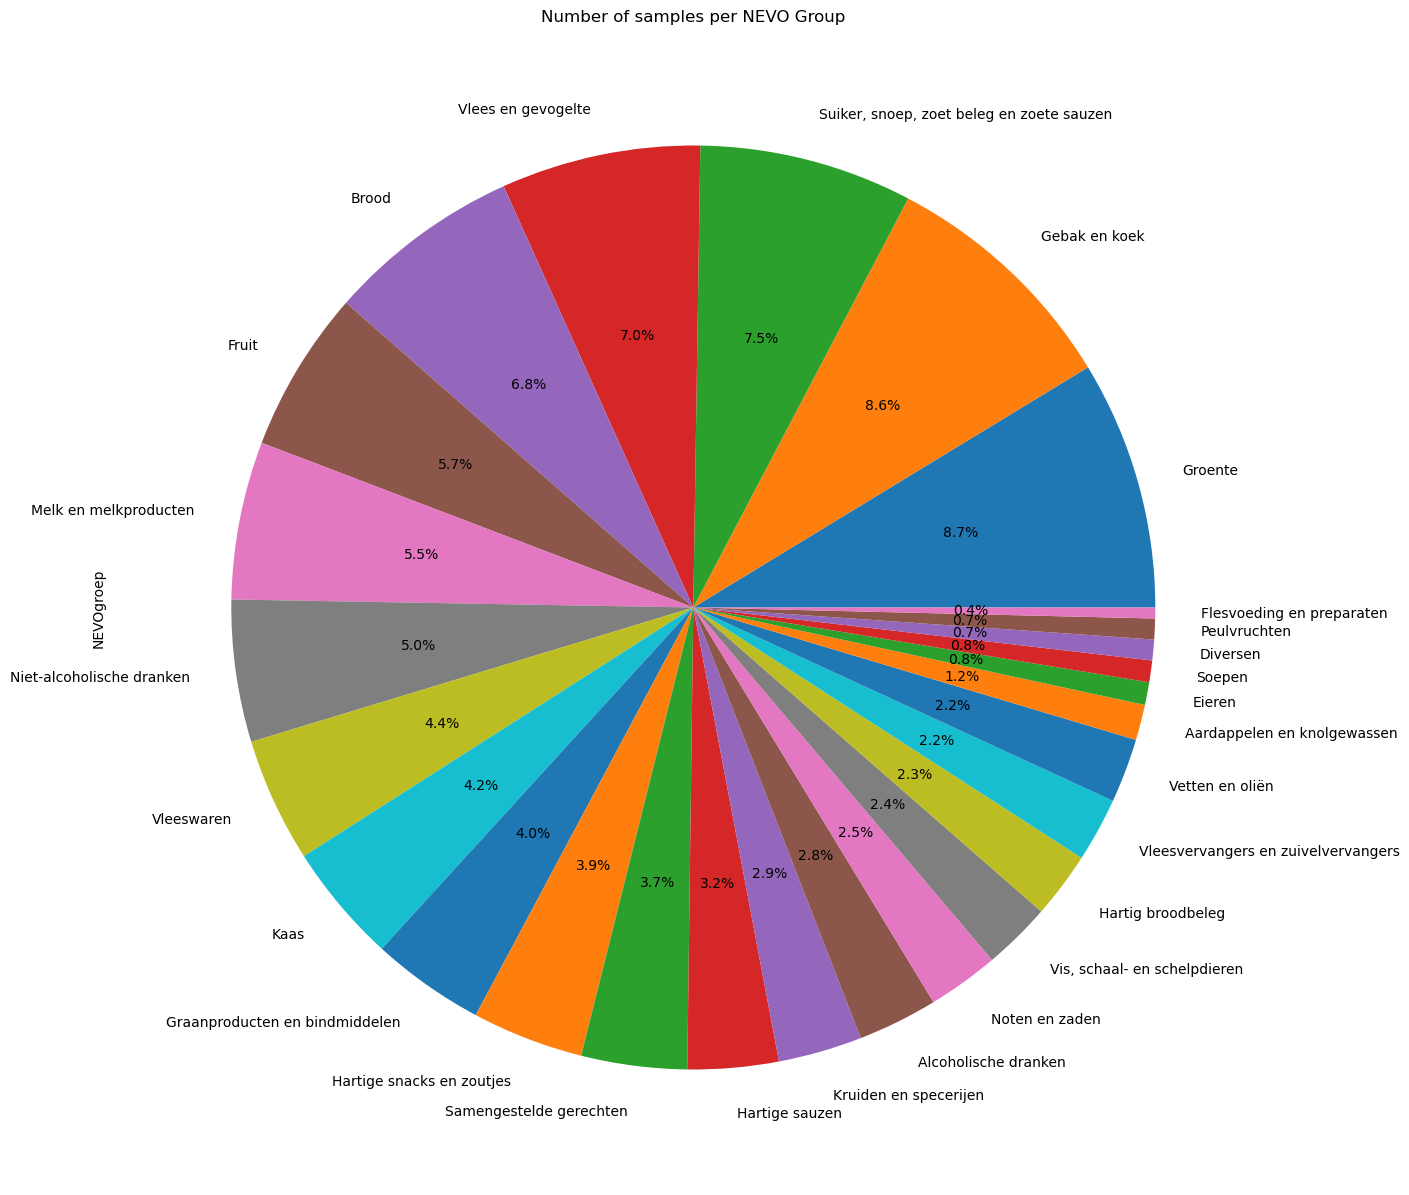

In [10]:
# count_per_category = fully_cleaned_data['NEVOgroep'].value_counts()
fully_cleaned_data['NEVOgroep'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(plot_figure_size_x, plot_figure_size_y))
plt.title('Number of samples per NEVO Group')
plt.show()

### Findings at the category level
We analyze the text and numerical data separately.

#### Numerical columns
Ideally, we see a clear separation in the box plots for each category for a specific numerical column. That would mean that the numerical column in question is a strong predictor of which category a food item belongs to. Even though we do not a perfect separation in all cases, there are strong correlations. 

1. If we look at the column `vettottaal_g`, we can see that any food item with a value above 60 probably belongs to the `Vetten en Olien` category. 
2. f we look at the column `vettottaal_g`, we can also see that there are samples for other food items (such as `Hartige sauzen`) that mostly have lower values for `vettottaal_g`, but some specific examples that do have unusually high `vettottaal_g`, which might cause them to be missclassified (if we would classify on this column alone). 
3. In other cases, such as for `energiewaardeinkcal_kcal`, we can see that there is no clear separation between the categories `Hartige sauzen`,  `Vleeswaren` and `Brood`, meaning that this column can not be used on its own as a strong predictor for the different categories.

It is important to note that we see a number of outliers for each category, over all the different numerical columns. If we want to improve our classification performance, it might be worth investing in anomaly detection and analysis. At a quick glance, some of these anomalies seem to be the result of misslabeling (more on that where we look at individual samples).


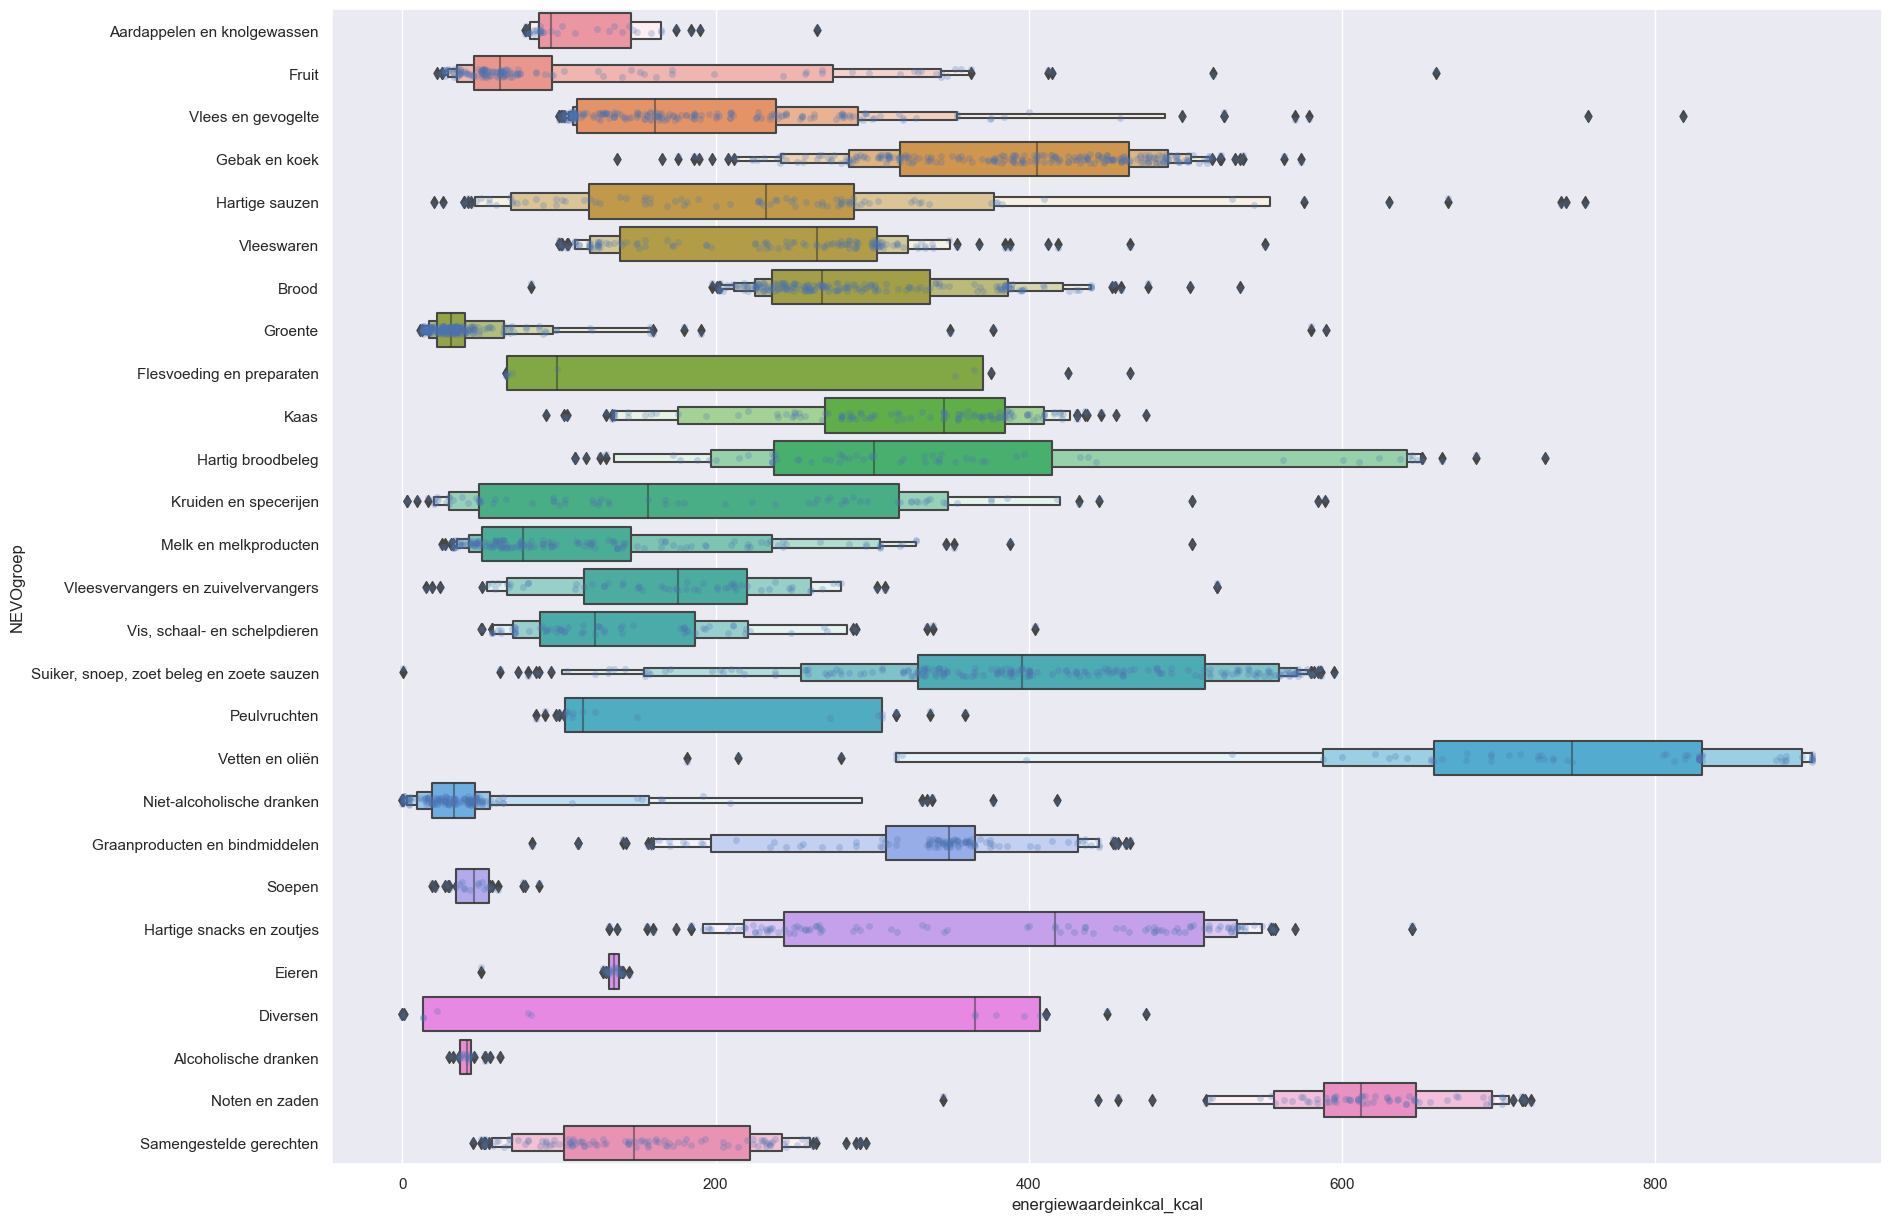

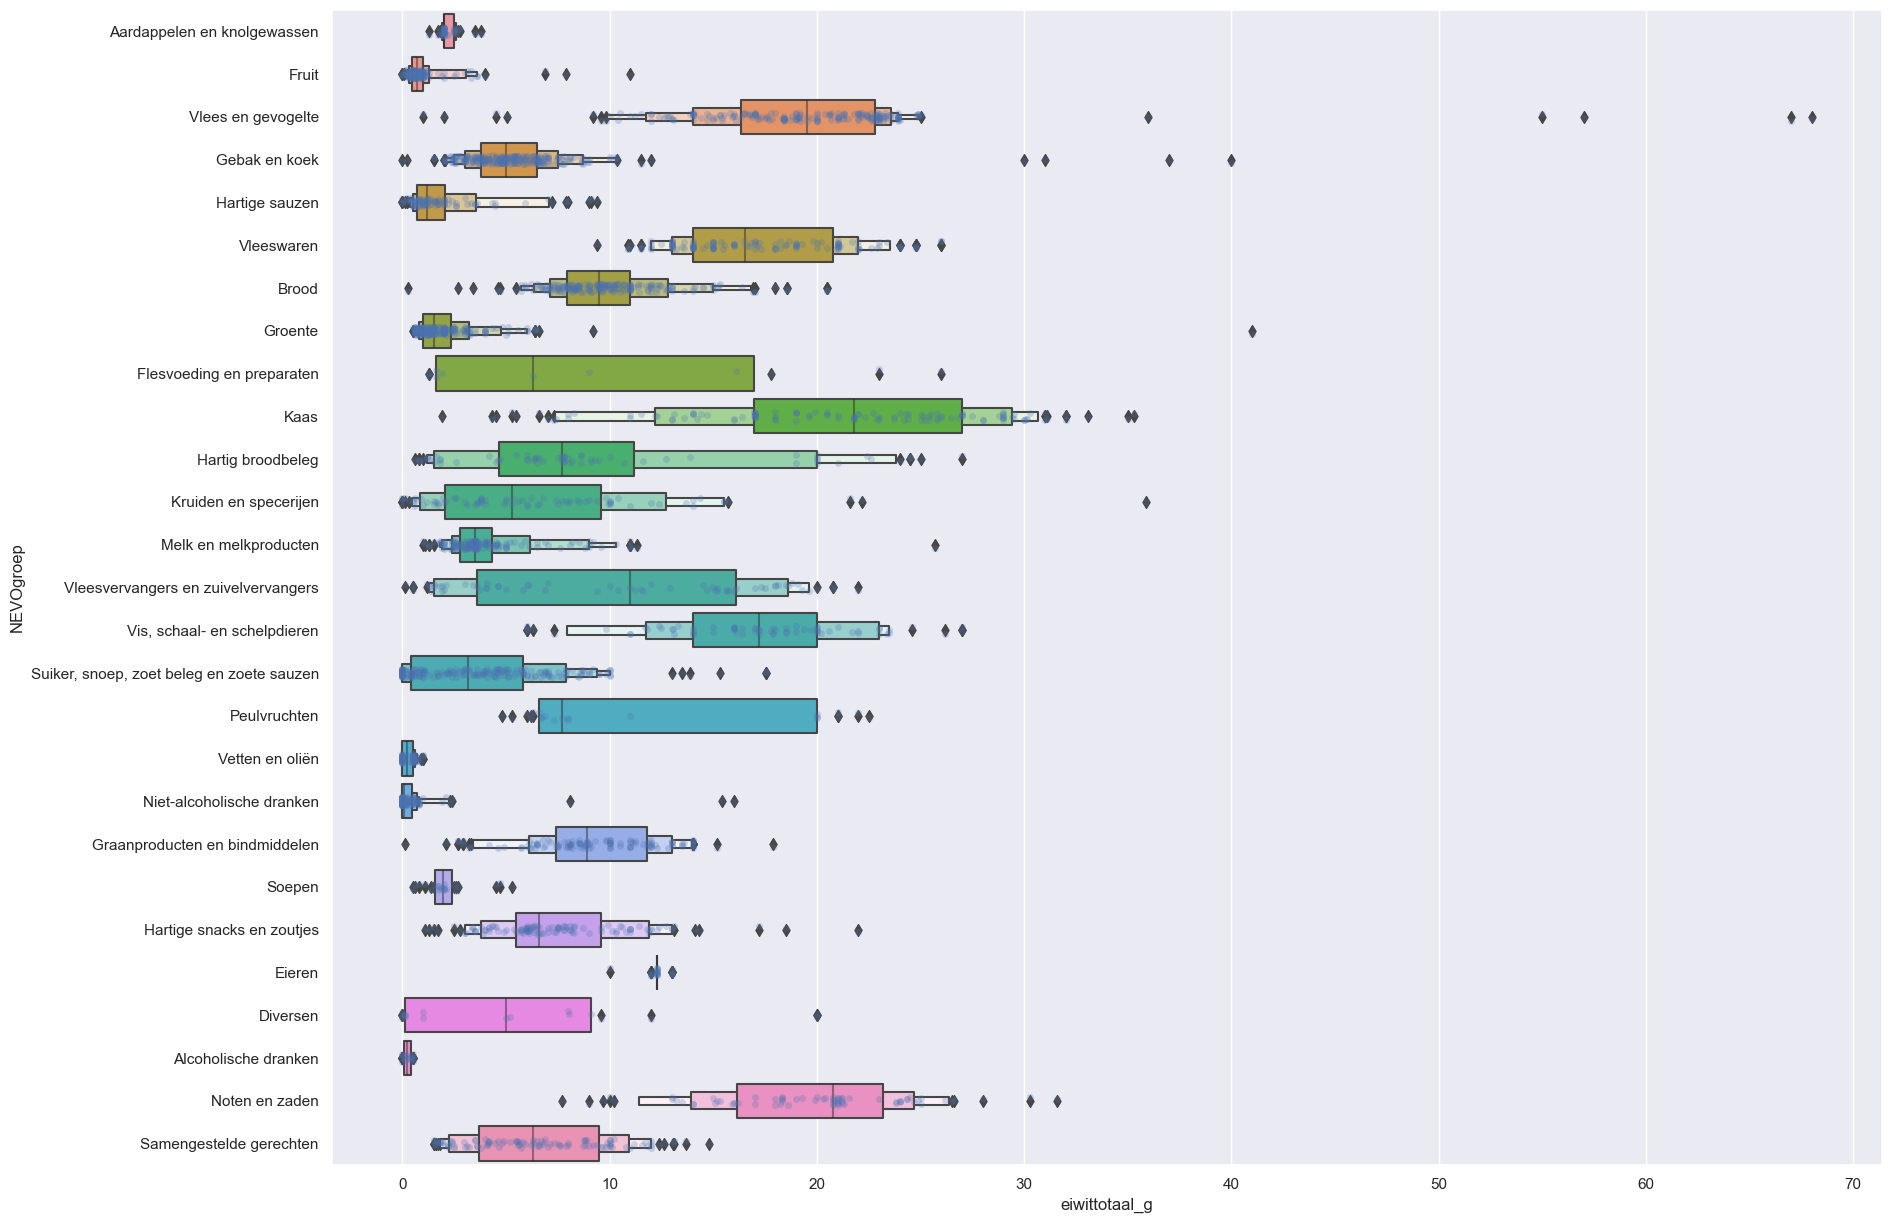

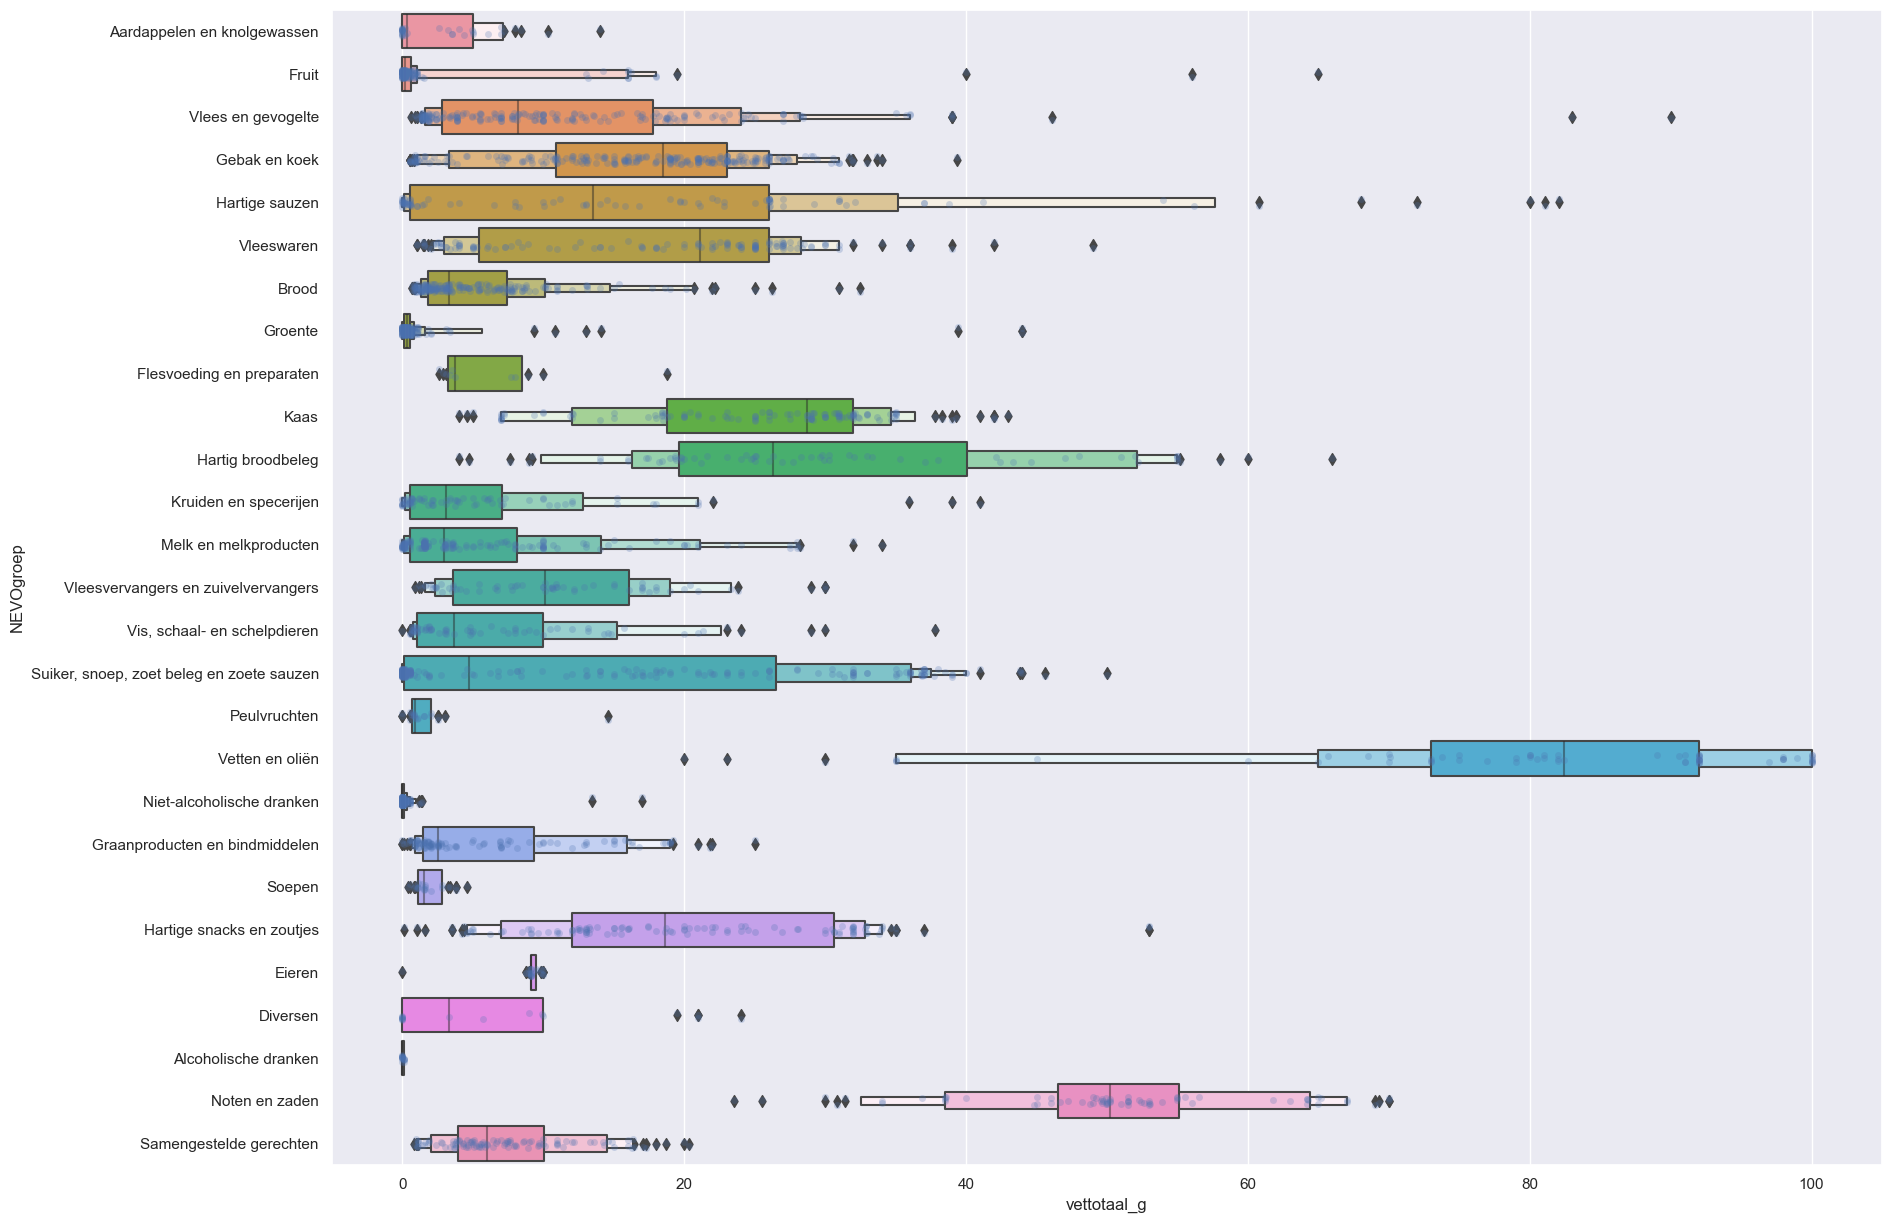

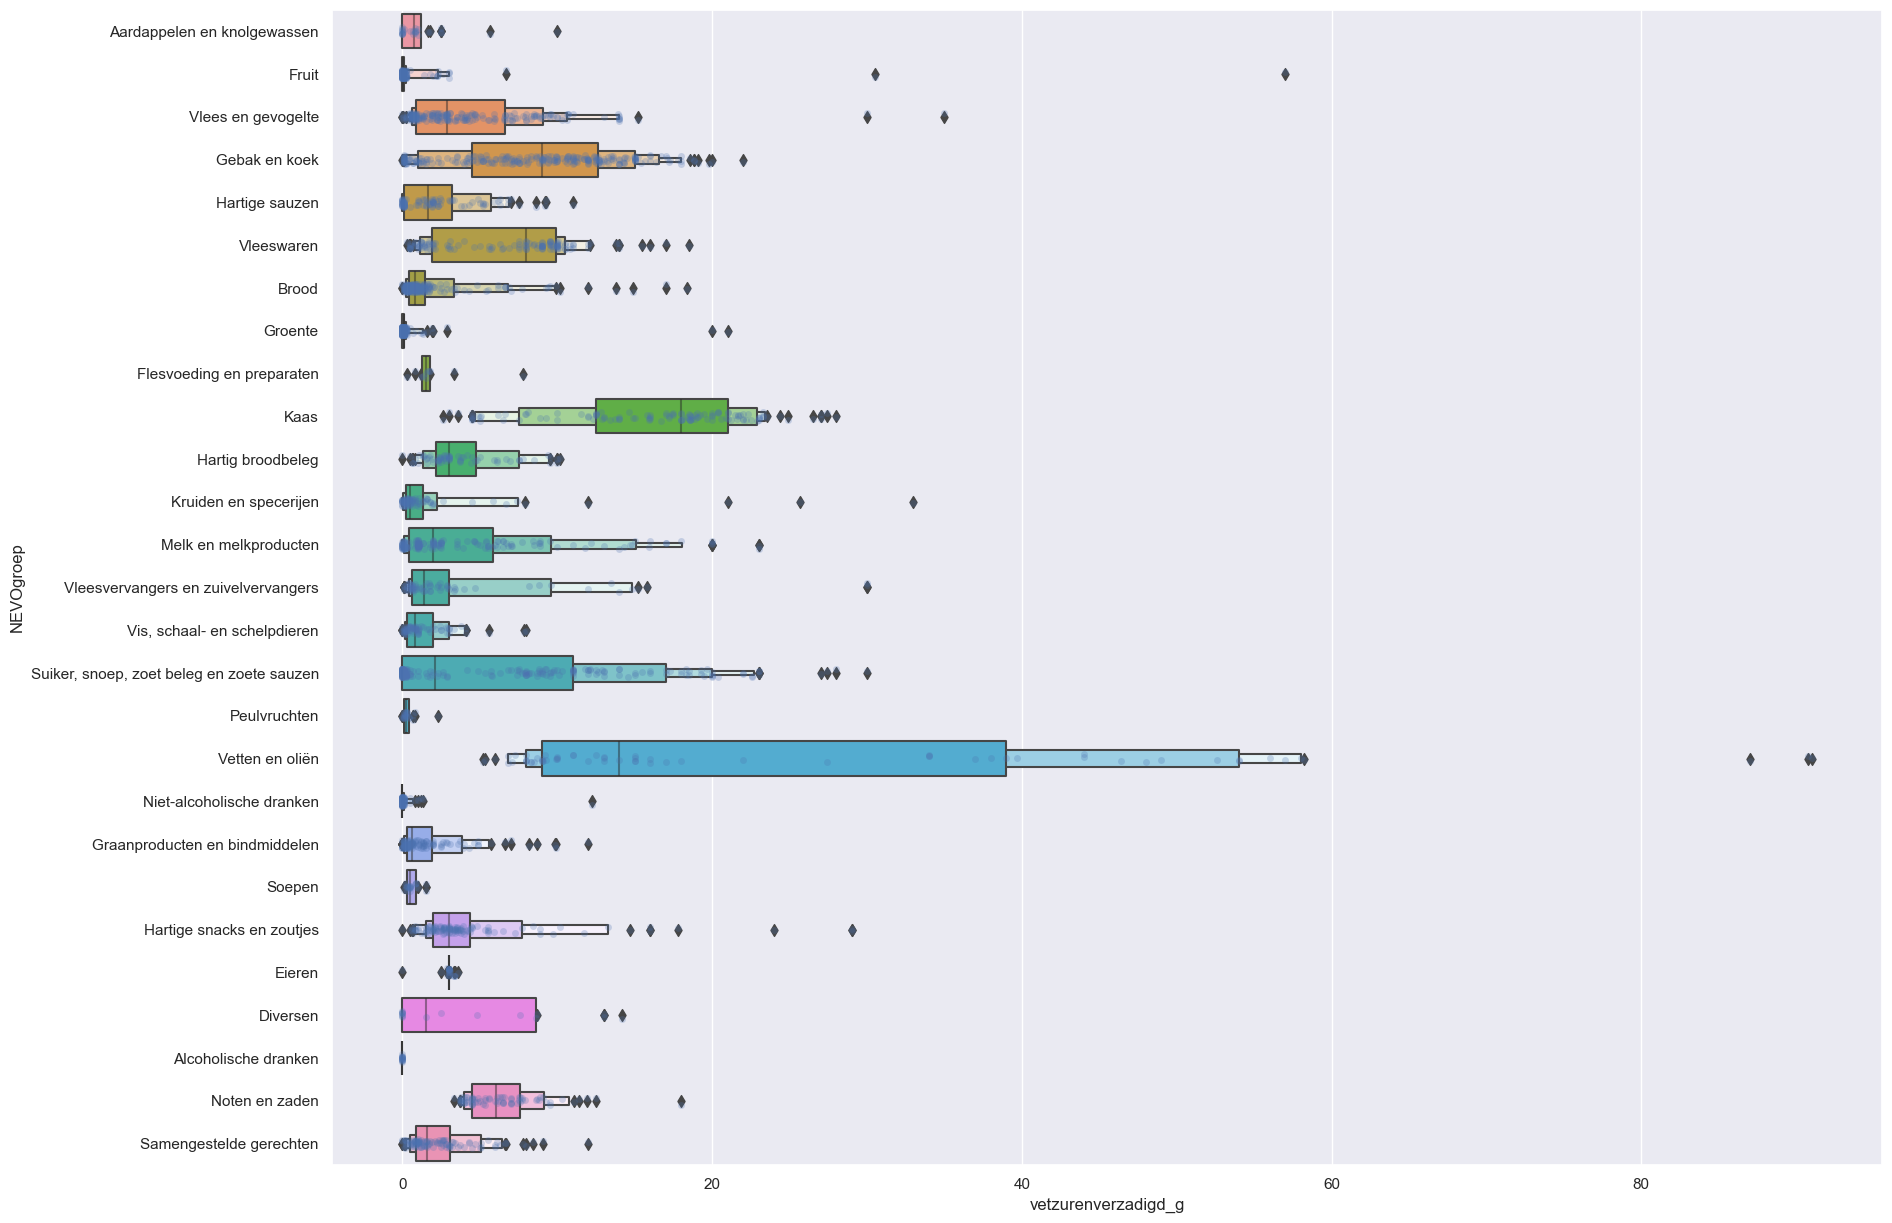

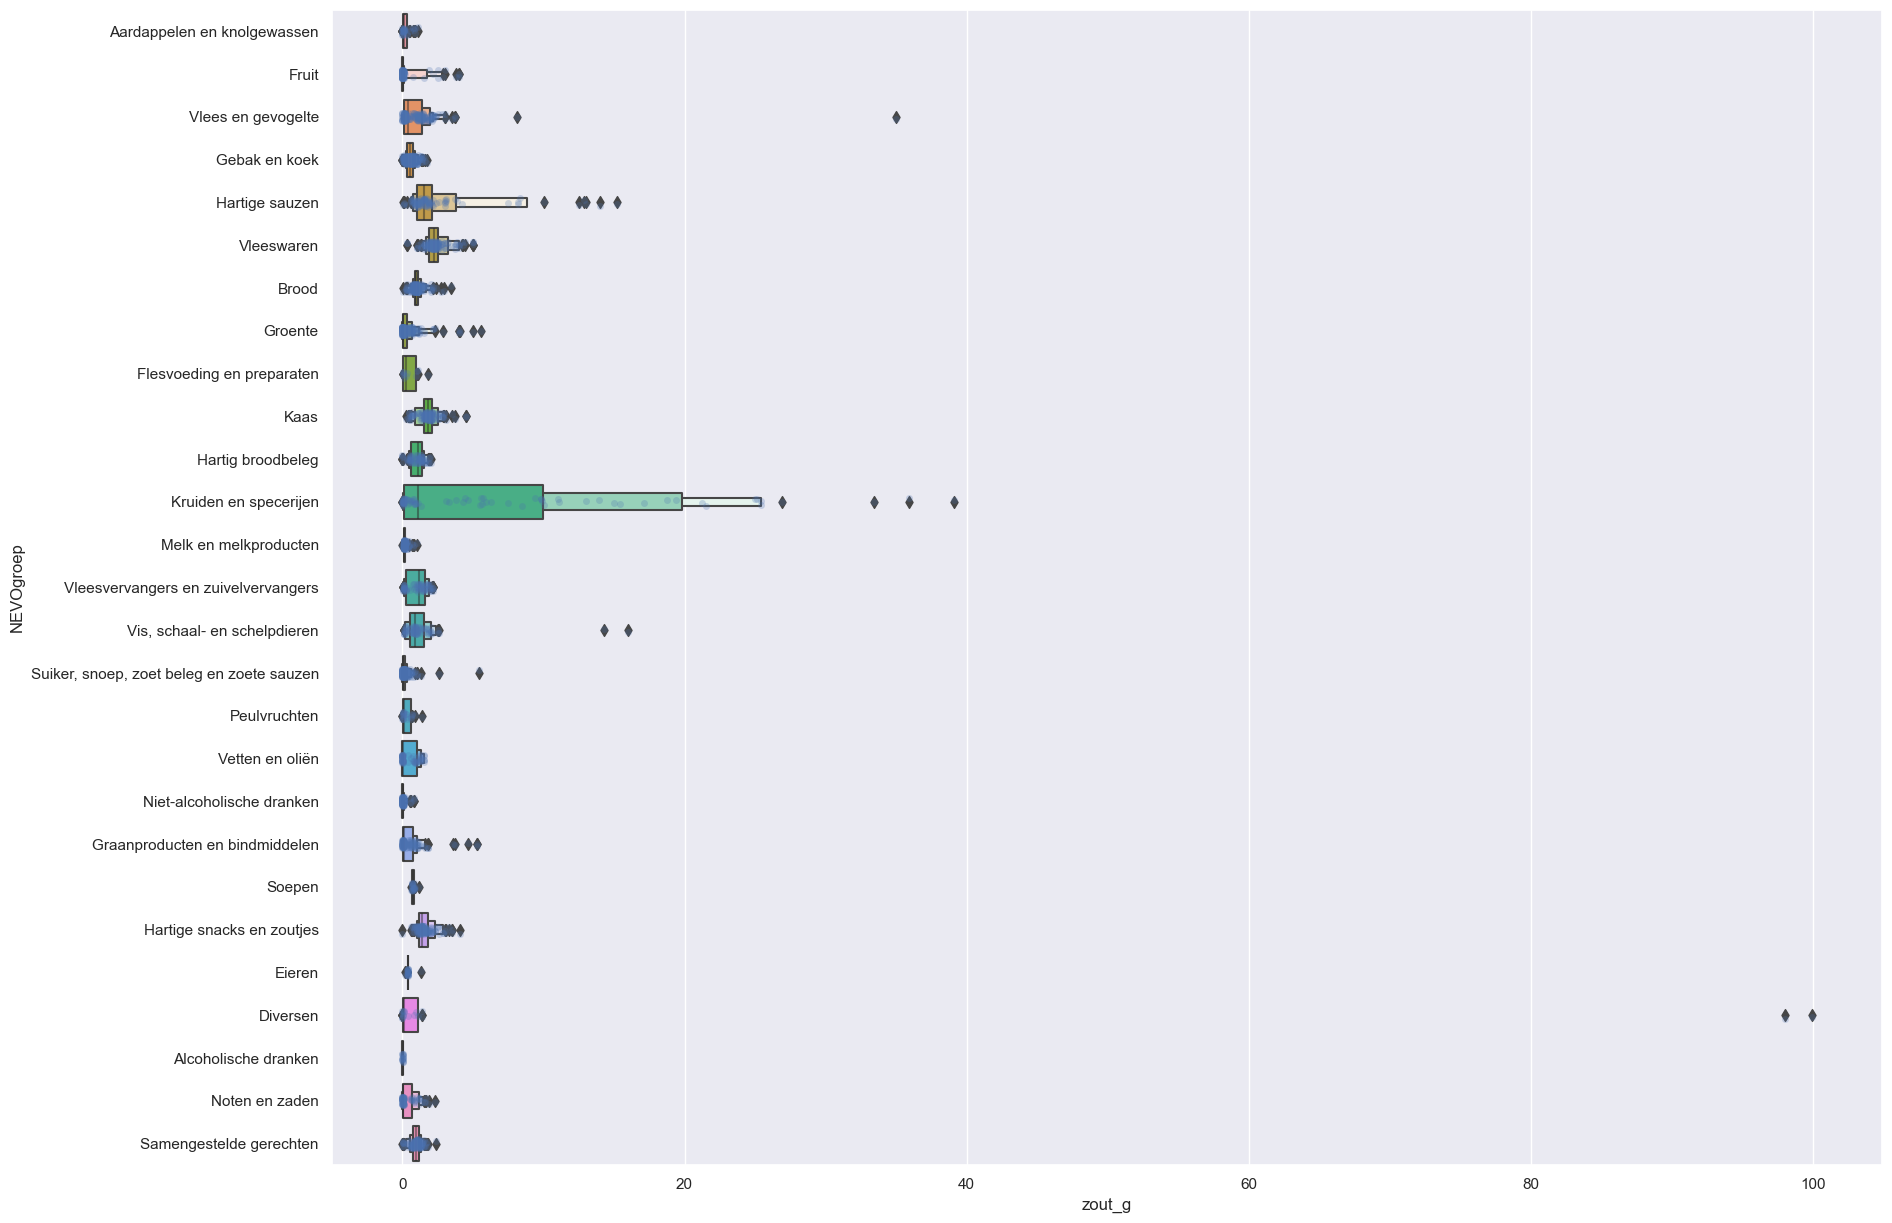

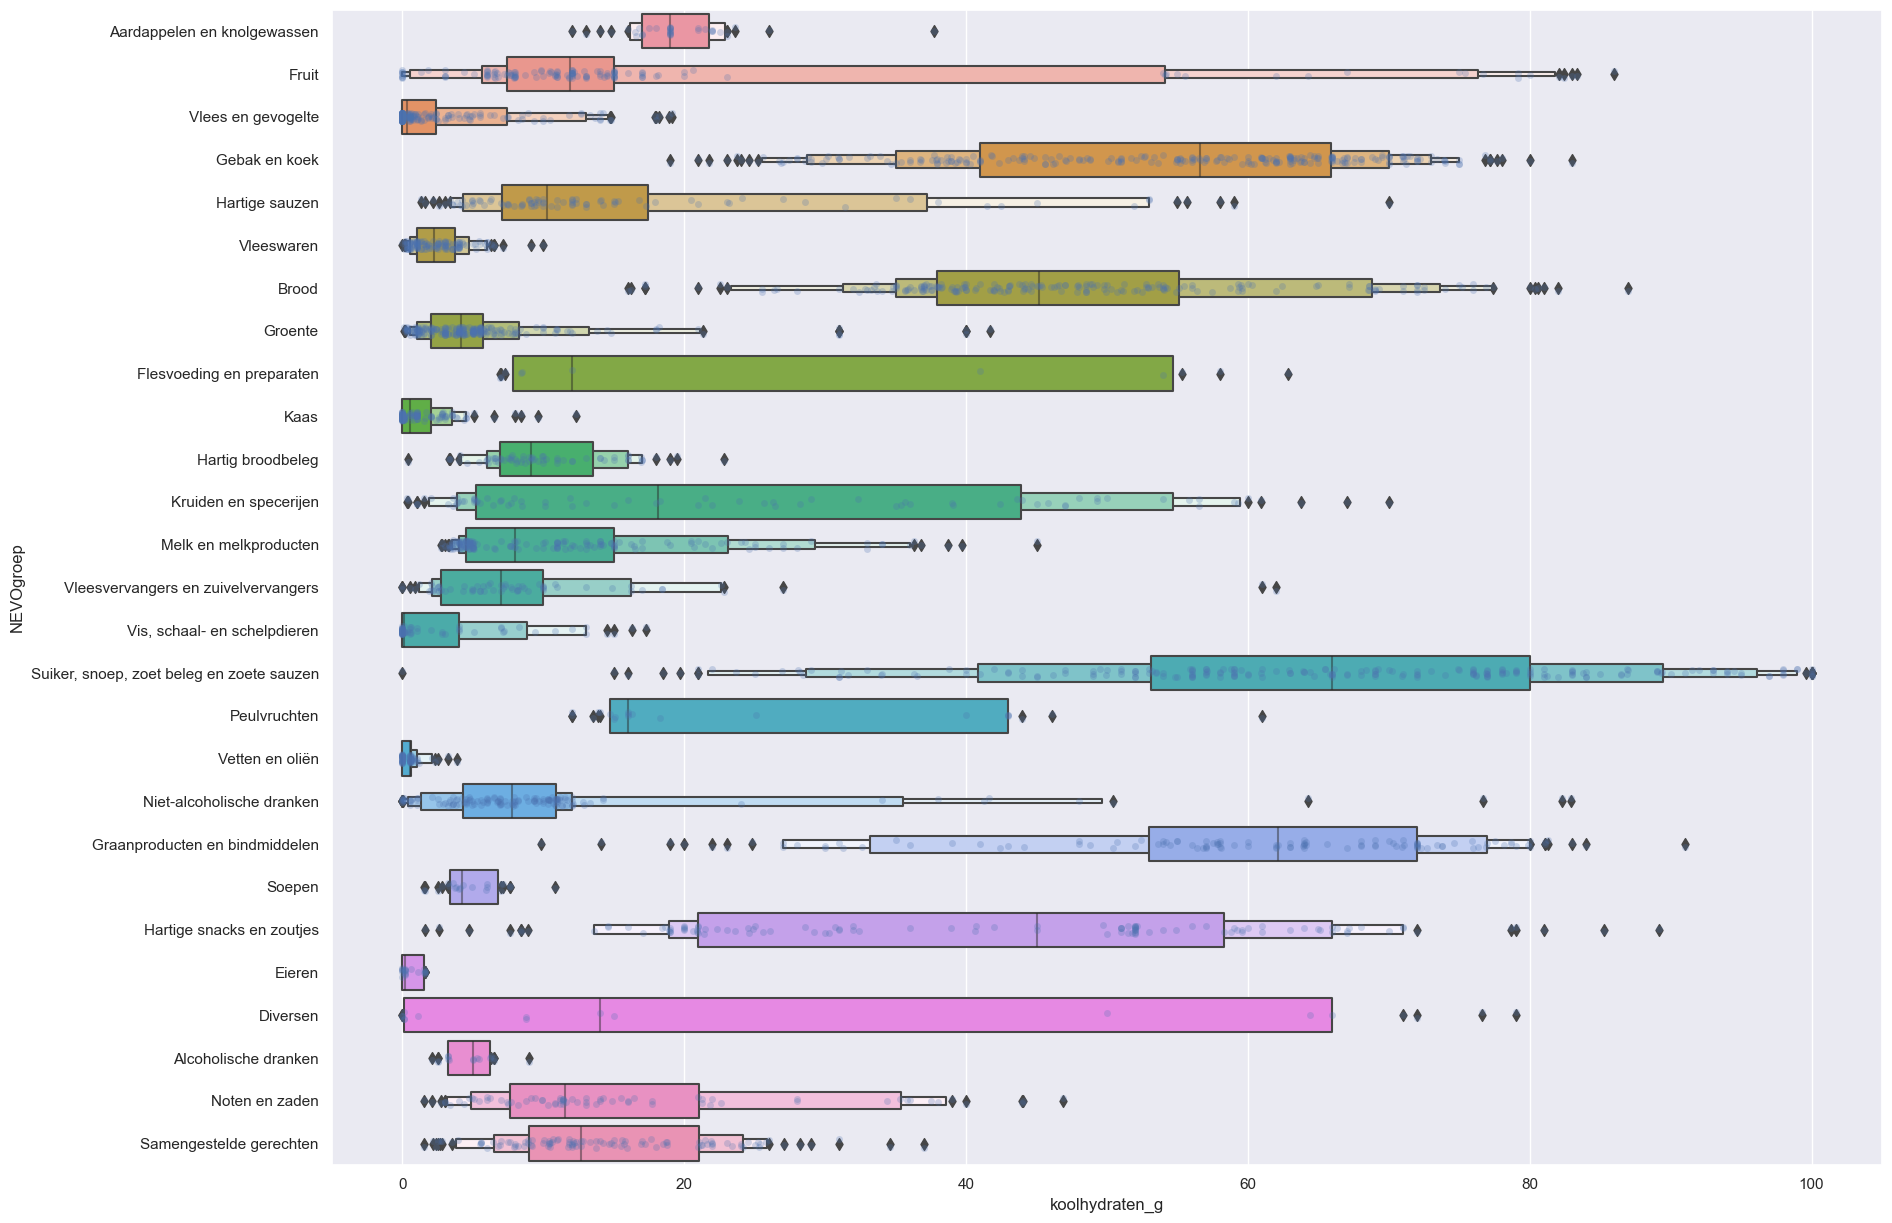

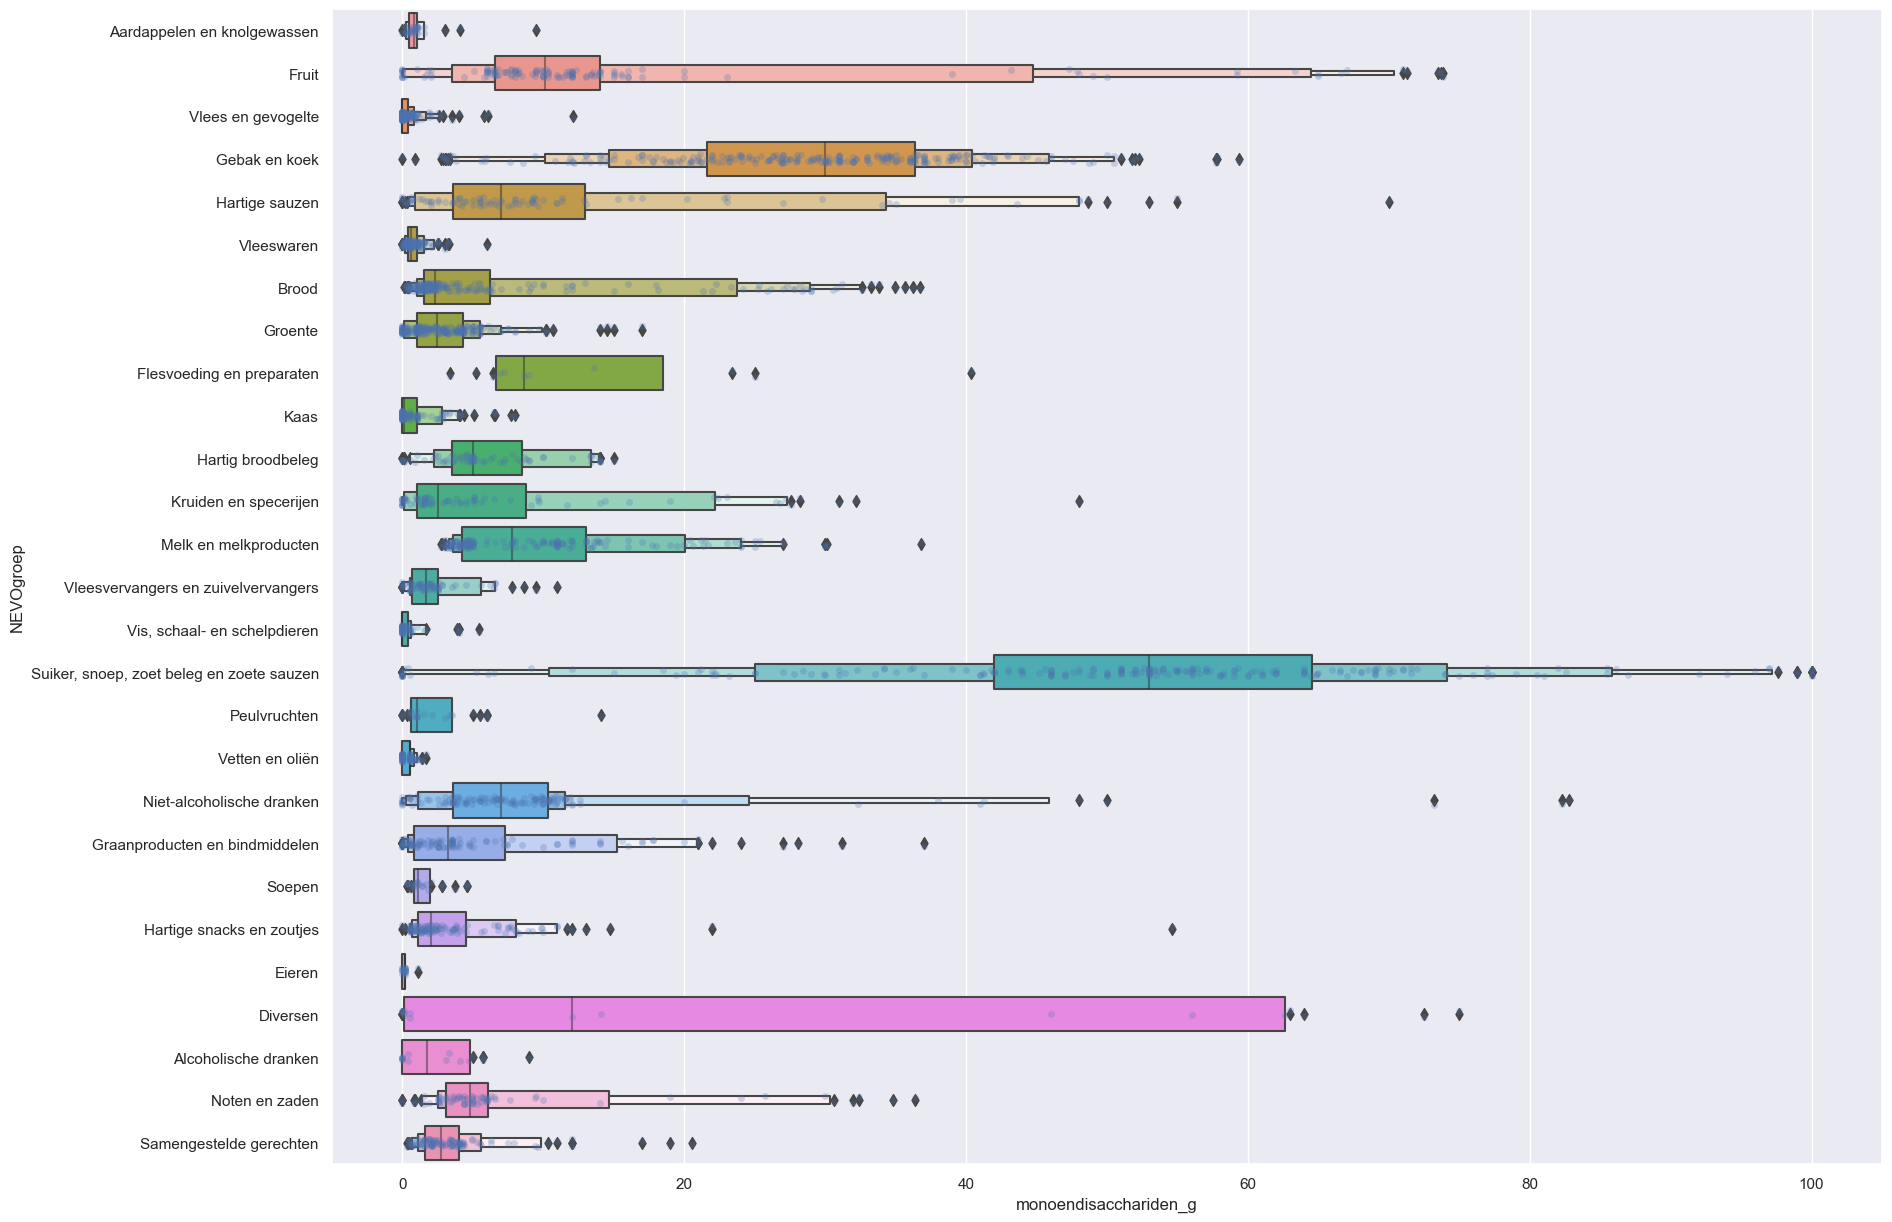

In [11]:
nutrition_columns: list = list(fully_cleaned_data.columns[2:-1])
sns.set_theme(rc={'figure.figsize':(plot_figure_size_x, plot_figure_size_y)})
for nutrition_column in nutrition_columns:
    data_to_plot = fully_cleaned_data[['NEVOgroep', nutrition_column]]
    fig = plt.figure()    

    sns.boxenplot(data=data_to_plot, x=nutrition_column, y='NEVOgroep')
    sns.stripplot(data=data_to_plot, x=nutrition_column, y='NEVOgroep', alpha=.25, legend=False)

#### Text columns
If we do some simple word counts for the `ingredienttekst` column for 2 different NEVO groups, we can see that we get some common ingredients and some destinct ingredients. For instance, we could identify `zout` as an ingredient that is common over all NEVO groups and has little value in trying to separate (e.g., categorize) the different examples into food groups based on their ingredients. However, `zuursel` or `stremsel` seem to be more specific to the `Kaas` NEVO group, as these do not occur in `samengestelde gerechten`. 

If we look at the `ingredienttekst` column tokens for `samengestelde gerechten`, we can see that the top tokens are a bit generic (e.g, `suiker`, `ui`, `water`, etc). That could mean that the `ingredienttekst` column might not hold much predictive value for the `samengestelde gerechten` NEVO group at all.  

With more time, we could investigate this further to identify words that are specific for a category versus those that are generic across categories.

In [12]:
n = 10

all_samengestelde_gerechten_tokens_counter = get_column_token_count_for_category(
    data=fully_cleaned_data,
    category_column_name="NEVOgroep",
    category="Samengestelde gerechten",
    text_column_name="ingredienttekst"
)
top_samengestelde_gerechten_tokens = {k: all_samengestelde_gerechten_tokens_counter[k] for k in list(all_samengestelde_gerechten_tokens_counter)[:n]}

all_kaas_tokens_counter = get_column_token_count_for_category(
    data=fully_cleaned_data,
    category_column_name="NEVOgroep",
    category="Kaas",
    text_column_name="ingredienttekst"
)
top_kaas_tokens = {k: all_kaas_tokens_counter[k] for k in list(all_kaas_tokens_counter)[:n]}

print(f"Top {n} tokens for samengestelde gerechten:\n", top_samengestelde_gerechten_tokens)
print(f"Top {n} tokens for kaas:\n", top_kaas_tokens)

Top 10 tokens for samengestelde gerechten:
 {'zout,': 149, 'water,': 99, 'suiker,': 64, 'gemodificeerd': 47, 'ui,': 37, 'maïszetmeel,': 34, '(water,': 34, 'en': 34, 'azijn,': 32, 'aardappelzetmeel,': 30}
Top 10 tokens for kaas:
 {'zout,': 115, 'zuursel,': 81, 'stremsel,': 70, 'KOEMELK,': 40, '(MELK),': 34, 'dierlijk': 32, 'conserveermiddel:': 32, 'Gepasteuriseerde': 29, 'microbieel': 29, 'kleurstof:': 28}


In [13]:
# Getting the unique NEVO groups
list_of_food_categories = fully_cleaned_data['NEVOgroep'].unique()

# Initiate a dictionary to hold different types of information for each category.
analysis_grouped_by_food_category = {}

for food_category in list_of_food_categories:    
    analysis_grouped_by_food_category[food_category] = {}

    data_per_food_category = fully_cleaned_data[fully_cleaned_data["NEVOgroep"] == food_category]
    
    analysis_grouped_by_food_category[food_category]["data"] = data_per_food_category 
    analysis_grouped_by_food_category[food_category]["row_count"] = len(data_per_food_category)
    analysis_grouped_by_food_category[food_category]["summary_statistics"] = data_per_food_category.describe()

### Findings at individual record level

We want to look at individual rows to get a better understanding of the peculiarities of our dataset. 

If we look at records for the category `Fruit` where the `energiewaardeinkcal_kcal` is higher than 400, we can see that there are 2 rows (index 1356 and 2474) which are a likely mislabeled. This implies that the quality of the training data can be improved ("Garbage in, garbage out!"). Most likely, this will have an impact on our model performance. However, not being the subject matter expert, we cannot make any changes ourselves, but would have to collaborate with our expert colleagues. 

_Of course, we would go much deeper into inspecting individual rows if we would have more time!_

In [14]:
# records for the category `Fruit` where the `energiewaardeinkcal_kcal` is higher than 400.
fully_cleaned_data[
    (fully_cleaned_data["NEVOgroep"] == "Fruit") & (fully_cleaned_data["energiewaardeinkcal_kcal"] > 400)
]

,NEVOgroep,product_naam_f,energiewaardeinkcal_kcal,eiwittotaal_g,vettotaal_g,vetzurenverzadigd_g,zout_g,koolhydraten_g,monoendisacchariden_g,ingredienttekst
861,Fruit,Tropische Kokosbites 125g,415.0,4.0,40.0,30.5,0.063,3.0,1.0,kokos.
1356,Fruit,"Zachte feta blokjes 40+ met kruiden (2,5 kilog...",518.0,3.6,56.0,6.7,2.200,0.2,0.1,"Koolzaadolie 47%, groene en zwarte olijven 31%..."
2474,Fruit,dazels & viregen,412.0,7.9,16.2,1.4,0.023,55.5,43.2,"20% dadelstukjes (95% gedroogde dadel, rijsteb..."
2561,Fruit,Janssens Geraspte Kokos,660.0,6.9,65.0,57.0,0.090,7.4,7.4,kokos 100%.


### Data preprocessing

#### Text preprocessing

The usual preprocessing of text data often involves removing symbols and numbers. But in our data, for example, the "40+" in cheese can help the model classify it as cheese. Similarly, even though the norm is to remove words less than a length of 2 or 3, "g" or "l" can indicate that the food item is solid or liquid. Hence all the data has been kept for now. 

In [15]:
target_column = 'NEVOgroep'
text_columns = ['product_naam_f', 'ingredienttekst']
numerical_columns = [column for column in fully_cleaned_data 
                    if column not in text_columns and column != target_column]

# Replacing Nan's with string "NA"
text_columns_to_impute = fully_cleaned_data[text_columns]
text_imputer = SimpleImputer(strategy='constant', fill_value='NA')
imputed_text_columns = pd.DataFrame(data = text_imputer.fit_transform(text_columns_to_impute),
                                    columns = text_columns, index = text_columns_to_impute.index)

# Making all text lower case, removing punctuations, removing numbers, removing generic words
stopwords = ['en','het','de', 'van']

for column in imputed_text_columns:
    imputed_text_columns[column] = imputed_text_columns[column].str.lower()
    # imputed_text_columns[column] = imputed_text_columns[column].str.replace(r'[^\w\s]+', '', regex = True)
    # imputed_text_columns[column] = imputed_text_columns[column].str.replace('\d+', '', regex = True)
    imputed_text_columns[column] = [' '.join([item for item in x.split() 
                                    if item not in stopwords]) 
                                    for x in imputed_text_columns[column]]
    
# vectorizing the text     
text_features = []
vectorizer = CountVectorizer()

for column in text_columns:
    vectorized_text = vectorizer.fit_transform(imputed_text_columns[column])
    
    feature_names = [
     f"{column}_{feature_name}" 
     for feature_name in list(vectorizer.get_feature_names_out())
     ]
    
    count_vectors = vectorized_text.toarray()
    text_features.append(pd.DataFrame(data=count_vectors, columns=feature_names, index = imputed_text_columns.index))
    
processed_text_columns = pd.concat(text_features, axis=1, ignore_index=False)


#### Numerical preprocessing

In [16]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Maybe KNNImputer or mean value of the category
    ('scaler', MinMaxScaler())
])

# Replacing Nan's with mean of the column
numerical_columns_to_impute = fully_cleaned_data[numerical_columns]
num_imputer = SimpleImputer(strategy='mean')
imputed_numerical_columns = pd.DataFrame(data = num_imputer.fit_transform(numerical_columns_to_impute),
                                         columns = numerical_columns, index = numerical_columns_to_impute.index)

# Scaling each numerical feature to the range of (0, 1)
scaler = MinMaxScaler()
processed_numerical_columns = pd.DataFrame(data = scaler.fit_transform(imputed_numerical_columns),
                                           columns = numerical_columns,
                                           index = imputed_numerical_columns.index)

### Dimensionality reduction of text columns using LSA and KMeans clustering

Latent Semantic Analysis (LSA) is a technique in NLP similar to PCA used to reduce the dimensionality of vectprized text and capture the most important relationships between terms. After LSA reduces the dimensionality, KMeans clustering can effectively group similar terms based on their semantic content.

In [18]:
lsa = TruncatedSVD(n_components=2500)
X_lsa = lsa.fit_transform(processed_text_columns)

explained_variance = lsa.explained_variance_ratio_.sum()
print(f"Explained variance of the LSA step: {explained_variance * 100:.1f}%")

n_clusters = 27
X_kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit_transform(X_lsa) # Adjust the number of clusters as needed

kmeans_text_columns = pd.DataFrame(data = X_kmeans, columns = ["column" + str(c) for c in range(n_clusters)], index = processed_text_columns.index)

Explained variance of the LSA step: 99.3%


### Defining models and hyperparameters

Many classifier models were tested and Random Forest (RF) classifier performed the best of all the models. So only the RF classifier model is retained given the limited time for analysis.

In [19]:
# Define models and hyperparameters
models = {
    'Random_Forest': RandomForestClassifier()
}

param_grids = {
    'Random_Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__bootstrap': [True, False]
    },
}

### Model training

In [21]:
# def ideal_training():

best_models = {}

dim_reduce = True

for model_name, model in models.items():
    pipeline = Pipeline(steps=[  
        ('classifier', model)
    ])

    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grids[model_name], cv=5, scoring='accuracy', n_jobs = -1)

    # Split data
    if dim_reduce:
        X = pd.concat([kmeans_text_columns, processed_numerical_columns], axis=1, ignore_index=False)

    else:
        X = pd.concat([processed_text_columns, processed_numerical_columns], axis=1, ignore_index=False)

    y = fully_cleaned_data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # oversampling the train dataset using SMOTE
    smt = SMOTE(random_state=42)

    X_train, y_train = smt.fit_resample(X_train, y_train)

    # Train model
    grid_search.fit(X_train, y_train)

    # Best model
    best_models[model_name] = grid_search.best_estimator_

### Model testing: Evaluate all models

Random_Forest Evaluation:
Accuracy: 0.76
Precision: 0.78
Recall: 0.76
F1 Score: 0.76
Classification Report: 
                                           precision    recall  f1-score   support

              Aardappelen en knolgewassen       0.60      0.50      0.55         6
                     Alcoholische dranken       0.70      0.73      0.71        22
                                    Brood       0.86      0.90      0.88        42
                                 Diversen       0.00      0.00      0.00         2
                                   Eieren       1.00      1.00      1.00         5
                Flesvoeding en preparaten       0.67      0.50      0.57         4
                                    Fruit       0.70      0.68      0.69        28
                            Gebak en koek       0.83      0.91      0.87        44
           Graanproducten en bindmiddelen       0.64      0.78      0.70        18
                                  Groente       0.80      0.

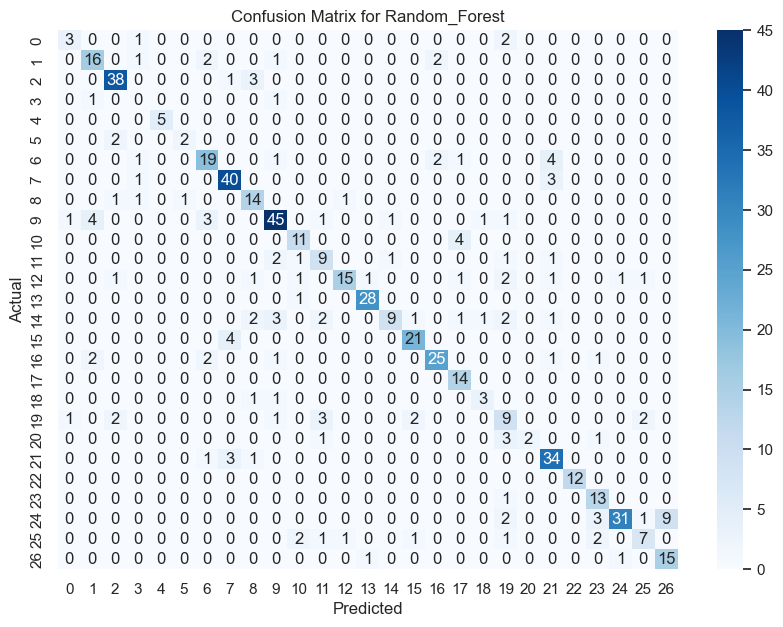

In [22]:
for model_name, best_model in best_models.items():
    y_pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted') 
    recall = recall_score(y_test, y_pred, average='weighted') 
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f'{model_name} Evaluation:') 
    print(f'Accuracy: {accuracy:.2f}') 
    print(f'Precision: {precision:.2f}') 
    print(f'Recall: {recall:.2f}') 
    print(f'F1 Score: {f1:.2f}')

    report = classification_report(y_test, y_pred, target_names=best_model.named_steps['classifier'].classes_)
    print('Classification Report: ')
    print(report)

    # Confusion Matrix 
    conf_matrix = confusion_matrix(y_test, y_pred, labels = best_model.named_steps['classifier'].classes_)
    plt.figure(figsize=(10, 7)) 
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues') 
    plt.title(f'Confusion Matrix for {model_name}') 
    plt.xlabel('Predicted') 
    plt.ylabel('Actual') 
    plt.show()

    # Get cross-validation results 
    cv_results = grid_search.cv_results_ 
    mean_test_score = cv_results['mean_test_score'][grid_search.best_index_] 
    std_test_score = cv_results['std_test_score'][grid_search.best_index_]

    # Store results
    evaluation_results = {}

    evaluation_results[model_name] = {
        'mean_cv_accuracy': mean_test_score, 
        'std_cv_accuracy': std_test_score,
        'test_accuracy': accuracy,
        'precision': precision, 
        'recall': recall, 
        'f1': f1, 
        'confusion_matrix': conf_matrix,
        'classification_report': report,
        'prediction_probabilities': proba
    }

### Model comparison: Compare models and find the best model

In [23]:
best_model_name = max(evaluation_results, key=lambda k: evaluation_results[k]['test_accuracy']) 
best_model = best_models[best_model_name]
print(f'Best Model: {best_model_name}') 
print(f'Best Model Accuracy: {evaluation_results[best_model_name]["test_accuracy"]:.2f}')

Best Model: Random_Forest
Best Model Accuracy: 0.76


### Result analysis
From the results below, we see that the classification performance per food group differs. Some groups that have very few sample are actually classified with a high degree of accuracy (e.g., `Eieren`) while other groups with few examples have no correctly classified samples (`Diversen`).

Other groups, such as `Vleeswaren`, `Vis-, schaal en schelpdieren` and `Vetten en olien` have higher sample count and high accuracy.  

A likely cause for these results is that groups that have low within-group variability and have high between-group variability are most easy to categorize.

In [72]:
y_pred = best_model.predict(X_test)

classified_foods = fully_cleaned_data.loc[list(y_test.index)]
classified_foods.insert(1, "predicted_NEVO_group", y_pred)
classified_foods.insert(2, "is_correct", (y_test == y_pred))

grouped_classified_foods = classified_foods.groupby('NEVOgroep')['is_correct'].value_counts().unstack().fillna(0)

for column_name in grouped_classified_foods.columns:
    grouped_classified_foods[column_name] = grouped_classified_foods[column_name].astype(int)

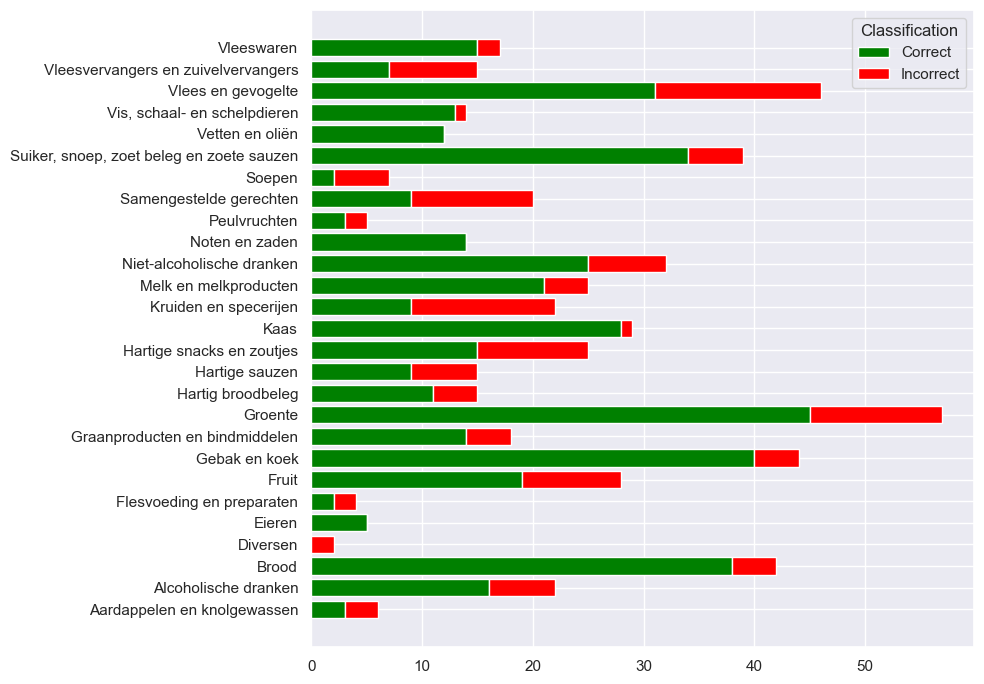

In [71]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 7)) 
plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True

NEVO_groups = list(grouped_classified_foods.index)
correctly_classified = list(grouped_classified_foods[grouped_classified_foods.columns[1]])
incorrectly_classified = list(grouped_classified_foods[grouped_classified_foods.columns[0]])

b1 = plt.barh(NEVO_groups, correctly_classified, color="green")

b2 = plt.barh(NEVO_groups, incorrectly_classified, left=correctly_classified, color="red")

plt.legend([b1, b2], ["Correct", "Incorrect"], title="Classification", loc="upper right")
plt.show()